# Modified 2D U-Net predictions across a cardiac scan

This notebook loads the best checkpoint from `unet2d_modified_100epoch_weighted_ce`, runs inference over one complete validation volume, and compares slices from low to high scan sections. Each row shows the preprocessed MR image, the predicted anatomical regions, and the ground truth.

In [1]:
from collections import defaultdict
from pathlib import Path
import json
import re
import sys

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'models').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'models').is_dir():
    raise FileNotFoundError('Open this notebook from the project root or the notebooks folder.')

sys.path.insert(0, str(PROJECT_ROOT))

from scripts.evaluate_common import (
    CLASS_NAMES,
    dice_score,
    keep_largest_connected_components_per_class,
    load_model,
)

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Project root: C:\Users\User\Desktop\VladanBasic\Automated-Cardiac-Diagnosis-Challenge
PyTorch: 2.12.1+cu126
CUDA available: True


## Settings

Leave `PATIENT_ID` and `FRAME_NUMBER` as `None` to automatically select a validation scan with anatomy present across many slices. Set either value to inspect a particular scan.

In [2]:
RUN_DIR = PROJECT_ROOT / 'runs' / 'unet2d_modified_100epoch_weighted_ce'
PATIENT_ID = None
FRAME_NUMBER = None
NUM_SLICES = 5
APPLY_LARGEST_COMPONENT_POSTPROCESSING = True
SAVE_FIGURE = False
FIGURE_PATH = PROJECT_ROOT / 'outputs' / 'unet2d_modified_weighted_ce_slice_comparison.png'

assert NUM_SLICES >= 1, 'NUM_SLICES must be at least 1.'

## Load the trained model and find available scans

In [3]:
model, model_name, config, checkpoint_path, device = load_model(
    RUN_DIR,
    model_name='unet2d_modified',
)

configured_data_dir = Path(config['args']['data_dir'])
DATA_DIR = configured_data_dir if configured_data_dir.is_absolute() else PROJECT_ROOT / configured_data_dir
validation_patients = {int(patient) for patient in config.get('val_patients', [])}
filename_pattern = re.compile(r'patient(\d+)_frame(\d+)_slice_(\d+)\.h5$')

scan_files = defaultdict(dict)
for path in sorted(DATA_DIR.glob('*.h5')):
    match = filename_pattern.fullmatch(path.name)
    if match is None:
        continue
    patient, frame, slice_index = map(int, match.groups())
    if validation_patients and patient not in validation_patients:
        continue
    scan_files[(patient, frame)][slice_index] = path

if not scan_files:
    raise FileNotFoundError(f'No canonical validation HDF5 slices found in {DATA_DIR}')

print(f'Model: {model_name}')
print(f'Checkpoint: {checkpoint_path.name}')
print(f'Device: {device}')
print(f'Validation scans found: {len(scan_files)}')

Model: unet2d_modified
Checkpoint: best_epoch_066.pt
Device: cuda
Validation scans found: 40


In [4]:
def foreground_slice_count(paths_by_index):
    count = 0
    for path in paths_by_index.values():
        with h5py.File(path, 'r') as h5_file:
            count += int(np.any(h5_file['label'][:] > 0))
    return count

candidate_keys = [
    key for key in scan_files
    if (PATIENT_ID is None or key[0] == PATIENT_ID)
    and (FRAME_NUMBER is None or key[1] == FRAME_NUMBER)
]
if not candidate_keys:
    raise ValueError(f'No validation scan matches patient={PATIENT_ID}, frame={FRAME_NUMBER}.')

scan_scores = {key: foreground_slice_count(scan_files[key]) for key in candidate_keys}
selected_key = max(candidate_keys, key=lambda key: (scan_scores[key], len(scan_files[key])))
selected_paths = [path for _, path in sorted(scan_files[selected_key].items())]

images = []
targets = []
slice_indices = []
phase = 'unknown'
for path in selected_paths:
    with h5py.File(path, 'r') as h5_file:
        images.append(h5_file['image'][:].astype(np.float32))
        targets.append(h5_file['label'][:].astype(np.uint8))
        slice_indices.append(int(h5_file.attrs.get('slice_index', len(slice_indices))))
        value = h5_file.attrs.get('phase', phase)
        phase = value.decode('utf-8') if isinstance(value, bytes) else str(value)

images = np.stack(images)
targets = np.stack(targets)

if phase == 'unknown':
    info_path = PROJECT_ROOT / 'ACDC' / 'database' / 'training' / f'patient{selected_key[0]:03d}' / 'Info.cfg'
    if info_path.exists():
        info = {}
        for line in info_path.read_text().splitlines():
            if ':' in line:
                key, value = line.split(':', 1)
                info[key.strip()] = value.strip()
        phase = 'ED' if info.get('ED') == str(selected_key[1]) else 'ES' if info.get('ES') == str(selected_key[1]) else phase

predicted_batches = []
for start in range(0, len(images), 8):
    batch = torch.from_numpy(images[start:start + 8, None]).to(device)
    with torch.inference_mode():
        logits = model(batch)
        predicted_batches.append(torch.argmax(logits, dim=1).cpu().numpy().astype(np.uint8))
predictions = np.concatenate(predicted_batches)

if APPLY_LARGEST_COMPONENT_POSTPROCESSING:
    predictions = keep_largest_connected_components_per_class(predictions)

patient, frame = selected_key
print(f'Selected patient {patient:03d}, frame {frame:02d}, phase {phase}')
print(f'Volume shape: {images.shape}; foreground slices: {scan_scores[selected_key]}')
print(f'Largest-component postprocessing: {APPLY_LARGEST_COMPONENT_POSTPROCESSING}')

Selected patient 092, frame 01, phase ED
Volume shape: (15, 224, 224); foreground slices: 15
Largest-component postprocessing: True


## Compare predictions with ground truth

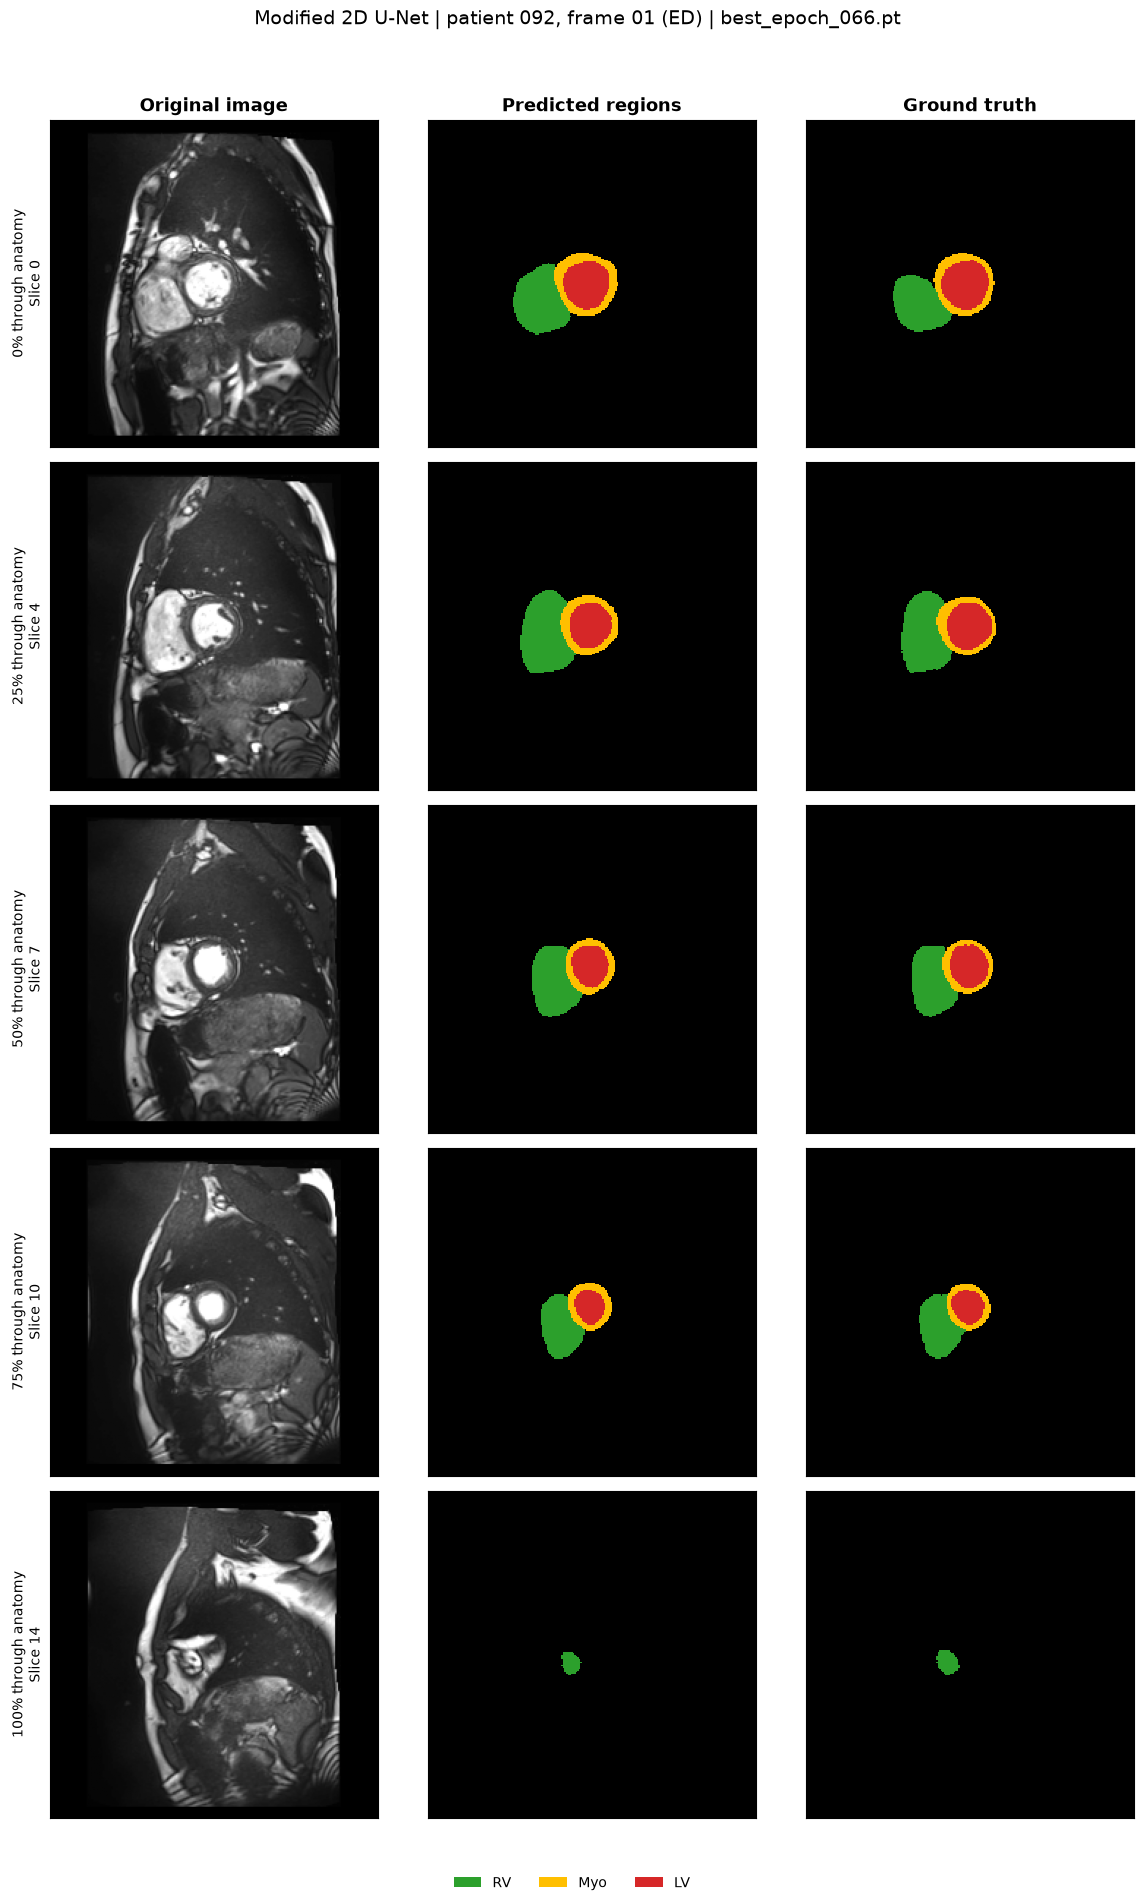

In [5]:
foreground_positions = np.flatnonzero(np.any(targets > 0, axis=(1, 2)))
selection_pool = foreground_positions if len(foreground_positions) else np.arange(len(images))
number_to_show = min(NUM_SLICES, len(selection_pool))
sample_positions = np.linspace(0, len(selection_pool) - 1, number_to_show).round().astype(int)
selected_positions = np.unique(selection_pool[sample_positions])

mask_cmap = ListedColormap(['#000000', '#2ca02c', '#ffbf00', '#d62728'])
mask_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], mask_cmap.N)
class_colors = {1: '#2ca02c', 2: '#ffbf00', 3: '#d62728'}
legend_handles = [
    Patch(facecolor=class_colors[class_id], label=CLASS_NAMES[class_id])
    for class_id in (1, 2, 3)
]

fig, axes = plt.subplots(len(selected_positions), 3, figsize=(12, 3.8 * len(selected_positions)), squeeze=False)
metric_rows = []
for row, position in enumerate(selected_positions):
    image = images[position]
    prediction = predictions[position]
    target = targets[position]
    low, high = np.percentile(image, [1, 99])

    axes[row, 0].imshow(image, cmap='gray', vmin=low, vmax=high)
    axes[row, 1].imshow(prediction, cmap=mask_cmap, norm=mask_norm, interpolation='nearest')
    axes[row, 2].imshow(target, cmap=mask_cmap, norm=mask_norm, interpolation='nearest')

    section_percent = 0 if len(selected_positions) == 1 else round(100 * row / (len(selected_positions) - 1))
    axes[row, 0].set_ylabel(f'{section_percent}% through anatomy\nSlice {slice_indices[position]}', fontsize=10)
    for class_id in (1, 2, 3):
        metric_rows.append({
            'slice': slice_indices[position],
            'section_percent': section_percent,
            'class': CLASS_NAMES[class_id],
            'dice': dice_score(prediction, target, class_id),
        })

for axis, title in zip(axes[0], ['Original image', 'Predicted regions', 'Ground truth']):
    axis.set_title(title, fontsize=13, weight='bold')
for axis in axes.flat:
    axis.set_xticks([])
    axis.set_yticks([])

fig.suptitle(
    f'Modified 2D U-Net | patient {patient:03d}, frame {frame:02d} ({phase}) | {checkpoint_path.name}',
    fontsize=14,
    y=0.995,
)
fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.035, 1, 0.975))

if SAVE_FIGURE:
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight')
    print(f'Saved figure: {FIGURE_PATH}')

plt.show()

## Slice-level Dice scores

A missing class in both masks has an undefined (`NaN`) Dice score and is excluded from the mean.

In [6]:
slice_metrics = pd.DataFrame(metric_rows)
display(slice_metrics.pivot(index=['section_percent', 'slice'], columns='class', values='dice').round(4))
print(f"Mean displayed foreground Dice: {slice_metrics['dice'].mean(skipna=True):.4f}")

,class,LV,Myo,RV
section_percent,slice,,,
0,0,0.9732,0.8881,0.9070
25,4,0.9535,0.8588,0.9536
50,7,0.9507,0.8745,0.9653
75,10,0.9544,0.8917,0.9817
100,14,NaN,NaN,0.8914


Mean displayed foreground Dice: 0.9265
